## Cyclical Encoding for Weekday (Notebook Outline)
1. Why Cyclical Encoding?  
Weekdays are cyclic (after Sunday comes Monday).  
Bad: integer labels (Mon=0,…,Sun=6) → treats 6 and 0 as far apart.  
Better: sine/cosine maps the day onto a circle so neighbors are close.  

2. Setup  
3. Naïve Encodings (for contrast)  
4. Cyclical Encoding (Sine & Cosine)  
    **Formula for cyclical encoding of a value `k` in a cycle of length `N`:**  
        x = sin(2 * π * k / N)    
        y = cos(2 * π * k / N)


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Example series of weekdays as integers: 0=Mon, ..., 6=Sun
weekday_series = pd.Series([0, 1, 2, 3, 4, 5, 6], name="weekday")

# One-hot encoding (works but loses cyclic adjacency)
one_hot = pd.get_dummies(weekday_series, prefix="weekday")
display(one_hot.head())


def cyclical_encode(series: pd.Series, period: int, colname: str):
    """
    Map integer-coded cyclical feature to sin/cos.
    series: integers in [0, period-1]
    period: size of cycle (e.g., 7 for weekdays)
    colname: base name for new columns
    """
    angle = 2 * np.pi * series.astype(float) / period
    return pd.DataFrame({
        f"{colname}_sin": np.sin(angle),
        f"{colname}_cos": np.cos(angle),
    })

weekday_cyc = cyclical_encode(weekday_series, period=7, colname="weekday")
weekday_cyc



,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
0,True,False,False,False,False,False,False
1,False,True,False,False,False,False,False
2,False,False,True,False,False,False,False
3,False,False,False,True,False,False,False
4,False,False,False,False,True,False,False


,weekday_sin,weekday_cos
0,0.000000,1.000000
1,0.781831,0.623490
2,0.974928,-0.222521
3,0.433884,-0.900969
4,-0.433884,-0.900969
5,-0.974928,-0.222521
6,-0.781831,0.623490


5. Attach to Your Dataset (pandas)  

In [25]:
# Example dataset with a date column
df = pd.DataFrame({
    "date": pd.date_range("2025-01-06", periods=10, freq="D")  # starts on a Monday
})

# Extract weekday as 0=Mon,...,6=Sun
df["weekday"] = df["date"].dt.weekday

# Cyclic features
df[["weekday_sin", "weekday_cos"]] = cyclical_encode(df["weekday"], period=7, colname="weekday")

df.head()


,date,weekday,weekday_sin,weekday_cos
0,2025-01-06,0,0.000000,1.000000
1,2025-01-07,1,0.781831,0.623490
2,2025-01-08,2,0.974928,-0.222521
3,2025-01-09,3,0.433884,-0.900969
4,2025-01-10,4,-0.433884,-0.900969


6. Distance Intuition: 7×7 Matrix (Mon–Sun)  
    Distances between encoded points show neighbors are close and opposite days are far.   

In [26]:
days = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
N = len(days)

# Coordinates for all weekdays
k = np.arange(N)
angles = 2 * np.pi * k / N
coords = np.column_stack((np.sin(angles), np.cos(angles)))  # shape (7,2)

# Euclidean distance matrix
dist = np.sqrt(((coords[:, None, :] - coords[None, :, :]) ** 2).sum(axis=2))
dist_df = pd.DataFrame(dist, index=days, columns=days).round(2)
dist_df


,Mon,Tue,Wed,Thu,Fri,Sat,Sun
Mon,0.00,0.87,1.56,1.95,1.95,1.56,0.87
Tue,0.87,0.00,0.87,1.56,1.95,1.95,1.56
Wed,1.56,0.87,0.00,0.87,1.56,1.95,1.95
Thu,1.95,1.56,0.87,0.00,0.87,1.56,1.95
Fri,1.95,1.95,1.56,0.87,0.00,0.87,1.56
Sat,1.56,1.95,1.95,1.56,0.87,0.00,0.87
Sun,0.87,1.56,1.95,1.95,1.56,0.87,0.00


7. Heatmap of Distances

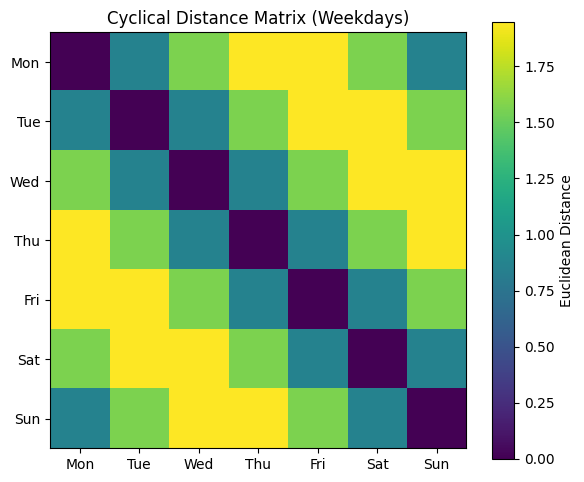

In [27]:
plt.figure(figsize=(6, 5))
im = plt.imshow(dist, cmap="viridis", interpolation="nearest")
plt.xticks(ticks=np.arange(N), labels=days)
plt.yticks(ticks=np.arange(N), labels=days)
plt.title("Cyclical Distance Matrix (Weekdays)")
cbar = plt.colorbar(im)
cbar.set_label("Euclidean Distance")
plt.tight_layout()
plt.show()


8. 2D Circle Plot (Optional Visual Aid)

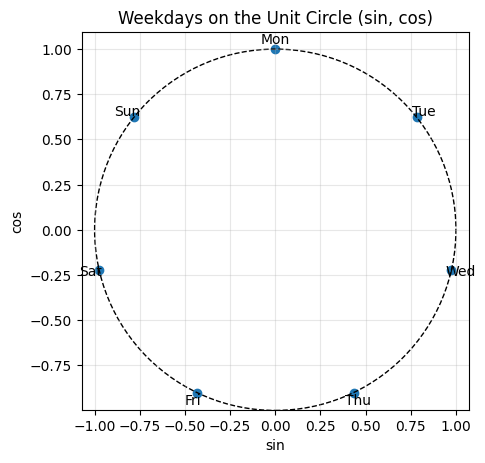

In [28]:
plt.figure(figsize=(5, 5))
plt.scatter(coords[:,0], coords[:,1])
for i, name in enumerate(days):
    plt.text(coords[i,0]*1.05, coords[i,1]*1.05, name, ha="center", va="center")
circle = plt.Circle((0,0), 1.0, fill=False, linestyle="--")
ax = plt.gca()
ax.add_artist(circle)
ax.set_aspect("equal", adjustable="box")
plt.title("Weekdays on the Unit Circle (sin, cos)")
plt.xlabel("sin")
plt.ylabel("cos")
plt.grid(True, alpha=0.3)
plt.show()


9. Using in Models  
    - Drop the raw integer weekday after encoding, keep weekday_sin, weekday_cos.
    - Works with linear models, tree models, neural nets.
    - For other cyclic features (e.g., hours of day, months), just change period.

In [29]:
# Example: keeping only cyclical features
X = df[["weekday_sin", "weekday_cos"]]  # model inputs


10. Quick Sanity Checks

In [30]:
# Check that neighbors (Mon-Tue, Sun-Mon) are closer than non-neighbors (Mon-Thu)
def pair_distance(a, b):
    i, j = days.index(a), days.index(b)
    return dist[i, j]

print("d(Mon, Tue) =", pair_distance("Mon","Tue"))
print("d(Sun, Mon) =", pair_distance("Sun","Mon"))
print("d(Mon, Thu) =", pair_distance("Mon","Thu"))


d(Mon, Tue) = 0.8677674782351161
d(Sun, Mon) = 0.8677674782351165
d(Mon, Thu) = 1.9498558243636472


## Notes  
If your original weekday is string (e.g., "Monday"), map to integers first.  
For hours: period=24; for months: period=12.  
You can keep one-hot in addition for some models, but sine/cos already capture adjacency well.  